In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [14]:
#data transaksi POS

transactions = [
    ['pen', 'bread', 'butter'],
     ['bread', 'butter', 'egg', 'milk'],
      ['vegetables', 'egg', 'milk'],
       ['bread', 'butter'],
       ['bread', 'butter', 'soy sauce', 'egg', 'milk']]

df = pd.DataFrame({"Products purchased": transactions})

total_transactions = len(df)
print(f'Total Transaksi: {total_transactions}')

df.head()

Total Transaksi: 5


,Products purchased
0,"[pen, bread, butter]"
1,"[bread, butter, egg, milk]"
2,"[vegetables, egg, milk]"
3,"[bread, butter]"
4,"[bread, butter, soy sauce, egg, milk]"


In [15]:
#Penbuat function support, confidence, & lift

def support(products):
  count = 0

  for transaction in transactions:
    #ubah ke set
    product_set = set(products)
    transaction_set = set (transaction)

    #cek apakah semua produk ada di transaksi
    if product_set.issubset(transaction_set):
      count += 1

  return count/total_transactions

def confidence(A, B):
  return support (A+B)/support(A)

def lift(A, B):
  return confidence(A, B) / support(B)

In [18]:
#list produk questin

list_products = [
    (['bread'], ['butter']),
    (['bread'], ['egg']),
    (['egg'], ['milk']),
    (['bread', 'butter'], ['milk'])
]

In [19]:
# Menghitung metrik

results = []

for A, B in list_products:
    sup = support(A + B)
    conf = confidence(A, B)
    lf = lift(A, B)

    results.append({
        'list products': f"{A} => {B}",
        'Support' : sup,
        'Confidence' : conf,
        'Lift': lf
    })

    result_df = pd.DataFrame(results)
    print(result_df)

             list products  Support  Confidence  Lift
0  ['bread'] => ['butter']      0.8         1.0  1.25
             list products  Support  Confidence      Lift
0  ['bread'] => ['butter']      0.8         1.0  1.250000
1     ['bread'] => ['egg']      0.4         0.5  0.833333
             list products  Support  Confidence      Lift
0  ['bread'] => ['butter']      0.8         1.0  1.250000
1     ['bread'] => ['egg']      0.4         0.5  0.833333
2      ['egg'] => ['milk']      0.6         1.0  1.666667
                     list products  Support  Confidence      Lift
0          ['bread'] => ['butter']      0.8         1.0  1.250000
1             ['bread'] => ['egg']      0.4         0.5  0.833333
2              ['egg'] => ['milk']      0.6         1.0  1.666667
3  ['bread', 'butter'] => ['milk']      0.4         0.5  0.833333


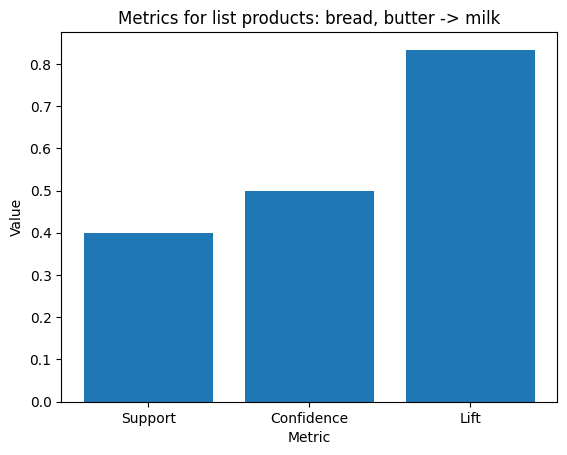

In [20]:
target_list_products = next(r for r in results if r['list products'] == "['bread', 'butter'] => ['milk']")

metrics = ['Support', 'Confidence', 'Lift']
values = [target_list_products[m] for m in metrics] 

plt.figure()
plt.bar(metrics, values)
plt.title("Metrics for list products: bread, butter -> milk")
plt.xlabel("Metric") 
plt.ylabel("Value")
plt.show()